# Titanic Survival Analysis

## About the project
An exploratory data analysis of the Titanic passenger dataset using Python and Pandas. The goal is to understand which factors were linked to passenger survival.

## Dataset
The data comes from the Kaggle competition **"Titanic - Machine Learning from Disaster"** (file: `train.csv`). It contains 891 passengers and 12 columns, including age, sex, ticket class, fare, and whether the passenger survived.

## Questions answered
1. What was the overall survival rate?
2. How did survival rate differ by gender?
3. How did survival rate differ by ticket class?
4. What was the average passenger age?
5. How can missing values in the `Age` column be handled?
6. Which had a stronger link to survival: gender or ticket class?

## Tools
Python, Pandas, Jupyter Notebook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

In [2]:
df = pd.read_csv('train.csv')
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Number of empty : Age and cabins and Embarked

df[['Age','Cabin','Embarked']].isna().sum()

Age         177
Cabin       687
Embarked      2
dtype: int64

In [6]:
#Overall survival rate
df[['Survived']].mean()

Survived    0.383838
dtype: float64

In [7]:
# Number of survivors(1) and  The Deceased(0)
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [8]:
# Survival rate by gender
# On the Titanic, the "women and children first" rule was applied, so a higher number of women survived.
# female ≈ 0.74 %
# male ≈ 0.19 %
# The survival rate for women is approximately 4 times that of men.
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [9]:
# Survival rate based on ticket class
# Conclusion: The class of the tickets also played a role in survival.
# "The higher the ticket class, the higher the survival rate."

df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [10]:
# "Gender was a stronger factor, but ticket class also had an independent effect."
# However, ticket class has also had an impact; for both genders, survival rates dropped as the class level decreased.
df.groupby(['Sex', 'Pclass'])['Survived'].mean()


Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [11]:
# Average age
df[['Age']].mean()

Age    29.699118
dtype: float64

In [12]:
# Filling in missing values ​​for the Age column
# Mean ≈ 29.7
# Median = 28
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age']


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [13]:
print(df['Age'].isna().sum())
print(df['Age'].mean())

0
29.36158249158249


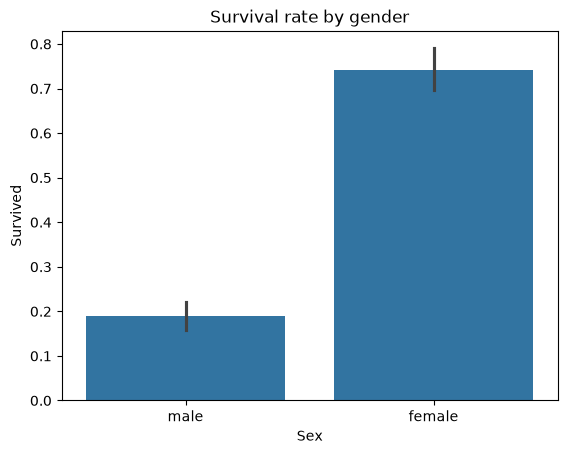

In [14]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival rate by gender')
plt.show()

Title: "Survival by gender"
Result: It is evident that gender has played a significant role in survival.


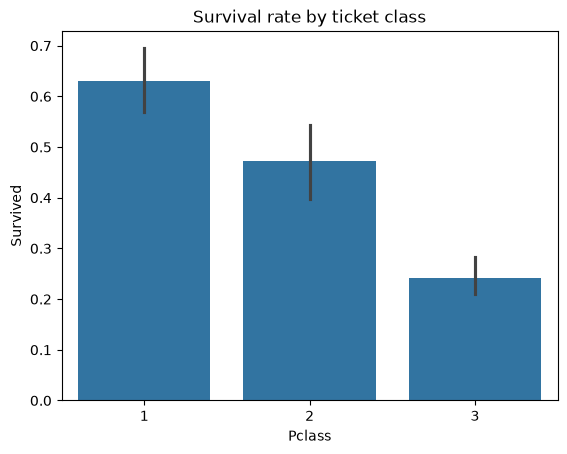

In [15]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival rate by ticket class')
plt.show()

Title: "Survival rate by ticket class"
Result:Ticket class alone also played a significant role in survival, though not as much as gender.

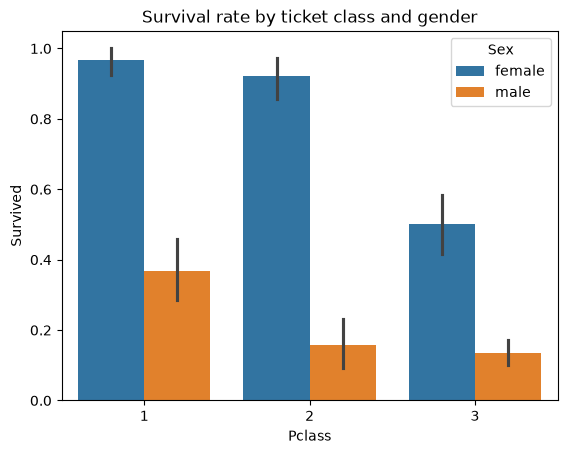

In [16]:
sns.barplot(x='Pclass' ,y='Survived',hue='Sex' ,data=df)
plt.title('Survival rate by ticket class and gender')
plt.show()

Title: "Survival Rate by Ticket Class and Gender"
Result: Based on what you saw today, gender had a stronger effect, and class also had an independent effect.

In [17]:
df[['Embarked']].isna().sum()

Embarked    2
dtype: int64

In [18]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [19]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'].isna().sum()

np.int64(0)

Calculating the number of family members = the individual (1) + (children, mother,  father) + (siblings and spouse).
Parch = children, mother,  father

In [20]:

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [21]:
df['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [22]:
df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

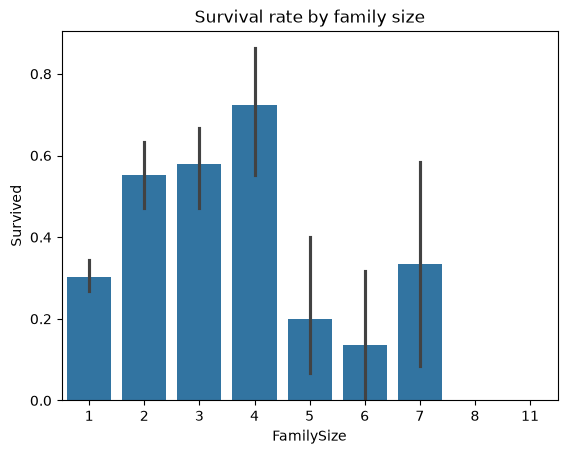

In [23]:
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival rate by family size')
plt.show()

 Result = "Solo travelers had a lower survival rate; families of two to four people had the highest rate, while larger families had a low rate, although the number of such groups is small."

In [24]:
df['FamilyGroup'] = pd.cut(df['FamilySize'],
                           bins=[0, 1, 4, 20],
                           labels=['Alone', 'Small', 'Large'])

In [25]:
df.groupby('FamilyGroup')['Survived'].mean()


FamilyGroup
Alone    0.303538
Small    0.578767
Large    0.161290
Name: Survived, dtype: float64

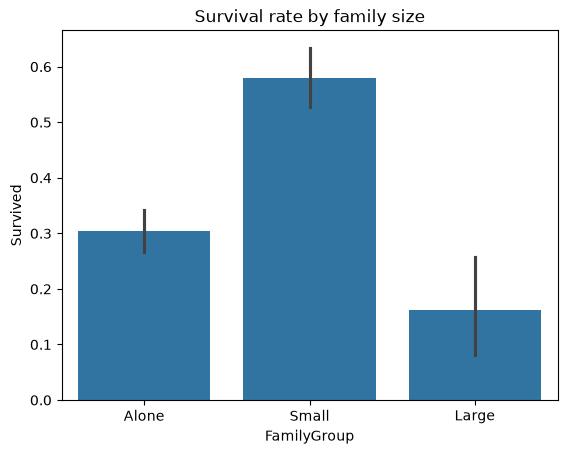

In [26]:
sns.barplot(x='FamilyGroup', y='Survived', data=df)
plt.title('Survival rate by family size')
plt.show()

In [27]:
df[['Name']].head()

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"


In [28]:
df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df[['Title']].head()

,Title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr


In [29]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Jonkheer      1
Name: count, dtype: int64

In [30]:
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'].value_counts()

Title
Mr          517
Miss        185
Mrs         126
Master       40
Dr            7
Rev           6
Major         2
Col           2
Don           1
Lady          1
Sir           1
Capt          1
Jonkheer      1
Name: count, dtype: int64

In [31]:
rare = ['Dr', 'Rev', 'Major', 'Col', 'Don', 'Lady', 'Sir', 'Capt', 'Jonkheer']
df['Title'] = df['Title'].replace(rare, 'Rare')
df['Title'].value_counts()


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       22
Name: count, dtype: int64

In [32]:
df.groupby('Title')['Survived'].mean()

Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.318182
Name: Survived, dtype: float64

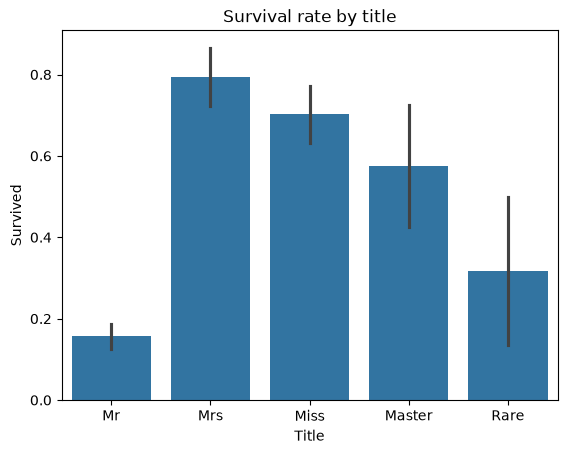

In [33]:
sns.barplot(x='Title', y='Survived', data=df)
plt.title('Survival rate by title')
plt.show()

 Result : Passenger status was strongly associated with survival: women had the highest survival rate, boys had a moderate rate, and men had the lowest. The number of individuals in the "rare" group was small, so the result is inconclusive.